In [1]:
# =========================
# Cell 1: Environment + Run Config (Reproducible)
# =========================

import os, random, time
import numpy as np

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

# ---- Torch checks ----
try:
    import torch
    print("torch:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("gpu:", torch.cuda.get_device_name(0))
        print("cuda:", torch.version.cuda)
        # Optional: speed up convs
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False
except Exception as e:
    print("Torch import failed:", e)

# ---- Run config (LOCKED v1) ----
CFG = {
    "seed": SEED,
    "num_frames": 16,
    "input_size": 224,
    "batch_size": 20,  # DFDC: (5R,5F) + DF: (5R,5F)
    "num_workers": 4,  # we will tune later (often 4-8)
    "max_epochs": 25,
    "min_epochs": 8,
    "early_stop_patience": 5,

    # temporal sampling
    "temporal_strides": [1, 2, 4],  # sampled uniformly

    # augmentation probabilities (finalized for RTX6000 Ada)
    "p_compress": 0.60,
    "p_res": 0.70,
    "p_noise": 0.50,
    "p_blur": 0.35,
    "p_cam_jitter": 0.40,
    "p_cutout": 0.25,
    "p_freq_drop": 0.25,
    "p_face_drop": 0.20,  # only if we implement bbox-based face dropout

    # domain adversarial (GRL)
    "grl_lambda_max": 0.05,  # ramp schedule later

    # regularization
    "label_smoothing": 0.05,
}

print("\n===== RUN BANNER =====")
for k in ["batch_size","num_frames","input_size","max_epochs","grl_lambda_max","label_smoothing"]:
    print(f"{k}: {CFG[k]}")
print("======================")

torch: 2.7.0+cu126
cuda available: True
gpu: NVIDIA RTX 6000 Ada Generation
cuda: 12.6

===== RUN BANNER =====
batch_size: 20
num_frames: 16
input_size: 224
max_epochs: 25
grl_lambda_max: 0.05
label_smoothing: 0.05


In [3]:
# =========================
# Cell 2: Load metadata + inspect
# =========================

import pandas as pd

META_PATH = "/home/unified_training_metadata.csv"
df = pd.read_csv(META_PATH)

print("Total rows:", len(df))
display(df.head())

print("\nUnique splits:", df['split'].unique())
print("Unique domains:", df['domain'].unique())
print("Unique labels:", df['class_label'].unique())

print("\nCounts by split:")
print(df['split'].value_counts())

print("\nCounts by domain & label:")
print(df.groupby(['domain','class_label']).size())

print("\nCounts by split & domain:")
print(df.groupby(['split','domain']).size())

Total rows: 18966


,path,split,domain,class_label,sampler_group
0,/home/DFDC_dataset/fake/qyyebirxwe.mp4,train,0,1,1
1,/home/DFDC_dataset/fake/ntjlknlcvn.mp4,val,0,1,1
2,/home/DFDC_dataset/fake/qivpypiwlp.mp4,train,0,1,1
3,/home/DFDC_dataset/fake/lpkgabskbw.mp4,train,0,1,1
4,/home/DFDC_dataset/fake/vctemjbusz.mp4,val,0,1,1



Unique splits: ['train' 'val' 'test']
Unique domains: [0 1]
Unique labels: [1 0]

Counts by split:
split
train    15433
val       2734
test       799
Name: count, dtype: int64

Counts by domain & label:
domain  class_label
0       0              1354
        1              7803
1       0              7829
        1              1980
dtype: int64

Counts by split & domain:
split  domain
test   0          799
train  0         7509
       1         7924
val    0          849
       1         1885
dtype: int64


In [4]:
# =========================
# Cell 3: Build index pools
# =========================

train_df = df[df.split == "train"].reset_index(drop=True)
val_df   = df[df.split == "val"].reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

def build_pools(dataframe):
    pools = {}
    for domain in sorted(dataframe.domain.unique()):
        for label in [0,1]:
            key = (domain, label)
            pools[key] = dataframe[
                (dataframe.domain == domain) &
                (dataframe.class_label == label)
            ].index.tolist()
            print(f"Domain {domain} Label {label}: {len(pools[key])} samples")
    return pools

train_pools = build_pools(train_df)
val_pools   = build_pools(val_df)

Train size: 15433
Val size: 2734
Domain 0 Label 0: 1083 samples
Domain 0 Label 1: 6426 samples
Domain 1 Label 0: 6296 samples
Domain 1 Label 1: 1628 samples
Domain 0 Label 0: 135 samples
Domain 0 Label 1: 714 samples
Domain 1 Label 0: 1533 samples
Domain 1 Label 1: 352 samples


In [5]:
# =========================
# Cell 4: Balanced Multi-Domain Sampler
# =========================

import random
from torch.utils.data import Sampler

class BalancedMultiDomainBatchSampler(Sampler):
    """
    Produces batches with fixed composition:
        DFDC: 5 real + 5 fake
        DeeperForensics: 5 real + 5 fake
    """

    def __init__(self, train_df, train_pools, batch_size=20):
        self.df = train_df
        self.pools = train_pools
        self.batch_size = batch_size
        
        # Fixed composition per batch
        self.per_group = 5  # per (domain, label)
        self.groups = [
            (0,0),  # DFDC real
            (0,1),  # DFDC fake
            (1,0),  # DF real
            (1,1)   # DF fake
        ]
        
        # Rough epoch length
        self.steps_per_epoch = len(train_df) // batch_size

        print("Steps per epoch:", self.steps_per_epoch)

    def __len__(self):
        return self.steps_per_epoch

    def sample_from_pool(self, pool, k):
        # sample WITH replacement (important for balancing)
        return random.choices(pool, k=k)

    def __iter__(self):
        for _ in range(self.steps_per_epoch):
            batch_indices = []

            for group in self.groups:
                pool = self.pools[group]
                batch_indices += self.sample_from_pool(pool, self.per_group)

            random.shuffle(batch_indices)
            yield batch_indices

In [6]:
# =========================
# Cell 5: Create sampler instance
# =========================

batch_sampler = BalancedMultiDomainBatchSampler(
    train_df=train_df,
    train_pools=train_pools,
    batch_size=CFG["batch_size"]
)

Steps per epoch: 771


In [7]:
# =========================
# Cell 6: Sanity check sampler output
# =========================

batch = next(iter(batch_sampler))
print("Batch size:", len(batch))

sample_batch_df = train_df.iloc[batch]

print("\nCounts inside one batch:")
print(sample_batch_df.groupby(['domain','class_label']).size())

Batch size: 20

Counts inside one batch:
domain  class_label
0       0              5
        1              5
1       0              5
        1              5
dtype: int64


In [9]:
!pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [41]:
# =========================
# cell 7
# Efficient video frame reader (NO full video loading)
# =========================

def read_video_frames(video_path, num_frames=16, strides=[1,2,4]):
    """
    Memory-safe frame sampling.
    We DO NOT load full video into RAM.
    """

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # choose stride mode
    stride = random.choice(strides)
    clip_len = num_frames * stride

    if total_frames >= clip_len:
        start = random.randint(0, total_frames - clip_len)
        frame_ids = [start + i*stride for i in range(num_frames)]
    else:
        frame_ids = np.linspace(0, total_frames-1, num_frames).astype(int)

    frames = []
    current_frame = 0
    target_idx = 0

    while cap.isOpened() and target_idx < len(frame_ids):
        ret, frame = cap.read()
        if not ret:
            break

        if current_frame == frame_ids[target_idx]:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
            target_idx += 1

        current_frame += 1

    cap.release()

    # safety fallback (rare)
    if len(frames) < num_frames:
        frames += [frames[-1]] * (num_frames - len(frames))

    return frames

In [42]:
# =========================
# Cell 8: Temporal sampling function
# =========================

import random
import numpy as np

def temporal_sample(frames, num_frames=16, strides=[1,2,4]):
    """
    Multi-scale temporal sampling.
    Always returns exactly 16 frames.
    """
    
    total = len(frames)
    stride = random.choice(strides)
    clip_len = num_frames * stride

    if total >= clip_len:
        start = random.randint(0, total - clip_len)
        indices = [start + i*stride for i in range(num_frames)]
    else:
        # fallback if video short
        indices = np.linspace(0, total-1, num_frames).astype(int)

    sampled = [frames[i] for i in indices]
    return sampled

In [43]:
# =========================
# Cell 9: Video Dataset
# =========================

class DeepfakeVideoDataset(Dataset):
    def __init__(self, dataframe, cfg):
        self.df = dataframe
        self.cfg = cfg
        self.num_frames = cfg["num_frames"]
        self.strides = cfg["temporal_strides"]
        self.size = cfg["input_size"]

    def __len__(self):
        return len(self.df)

    def resize_frame(self, frame):
        frame = cv2.resize(frame, (self.size, self.size))
        frame = frame / 255.0
        frame = np.transpose(frame, (2,0,1))  # HWC → CHW
        return frame.astype(np.float32)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        path = row.path
        label = row.class_label
        domain = row.domain

        frames = read_video_frames(path, self.num_frames, self.strides)

        frames = [self.resize_frame(f) for f in frames]
        video = np.stack(frames)  # T,C,H,W

        return torch.tensor(video), torch.tensor(label), torch.tensor(domain)

In [44]:
# =========================
# Cell 10: Dataset sanity test
# =========================

train_dataset = DeepfakeVideoDataset(train_df, CFG)

video, label, domain = train_dataset[0]

print("Video tensor shape:", video.shape)  # expect [16,3,224,224]
print("Label:", label.item())
print("Domain:", domain.item())

Video tensor shape: torch.Size([16, 3, 224, 224])
Label: 1
Domain: 0


In [45]:
# =========================
# Cell 11: Validation dataset
# =========================

val_dataset = DeepfakeVideoDataset(val_df, CFG)

print("Train videos:", len(train_dataset))
print("Val videos:", len(val_dataset))

Train videos: 15433
Val videos: 2734


In [46]:
# =========================
# Cell 12: DataLoaders
# =========================

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_sampler=batch_sampler,
    num_workers=CFG["num_workers"],
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True
)

In [47]:
# =========================
# Cell 13: Dataloader sanity test
# =========================

videos, labels, domains = next(iter(train_loader))

print("Batch video shape:", videos.shape)
print("Batch labels shape:", labels.shape)
print("Batch domains shape:", domains.shape)

print("\nBatch composition:")
import pandas as pd
tmp = pd.DataFrame({
    "domain": domains.numpy(),
    "label": labels.numpy()
})
print(tmp.groupby(["domain","label"]).size())

Batch video shape: torch.Size([20, 16, 3, 224, 224])
Batch labels shape: torch.Size([20])
Batch domains shape: torch.Size([20])

Batch composition:
domain  label
0       0        5
        1        5
1       0        5
        1        5
dtype: int64


In [48]:
!pip install timm -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [49]:
# =========================
# Load Video Swin 3D (Kinetics pretrained)
# =========================

from torchvision.models.video import swin3d_s, Swin3D_S_Weights

weights = Swin3D_S_Weights.KINETICS400_V1
backbone = swin3d_s(weights=weights)

print("Loaded Video Swin 3D pretrained on Kinetics-400")

Loaded Video Swin 3D pretrained on Kinetics-400


In [50]:
# Remove classification head → get features only
backbone.head = nn.Identity()

print("Backbone output dim:", backbone.num_features)

Backbone output dim: 768


In [51]:
device = "cuda"
backbone = backbone.to(device).eval()

# Dummy video: (B,C,T,H,W)
B, C, T, H, W = 2, 3, 16, 224, 224
x = torch.randn(B, C, T, H, W, device=device)

with torch.no_grad():
    feats = backbone(x)

print("Input shape:", x.shape)
print("Feature shape:", feats.shape)

# HARD ASSERTS
assert feats.ndim == 2 and feats.shape[0] == B, "Backbone output should be (B, D)."
assert feats.shape[1] == backbone.num_features, "Feature dim mismatch."

Input shape: torch.Size([2, 3, 16, 224, 224])
Feature shape: torch.Size([2, 768])


In [52]:
import torch
import torch.nn as nn
from torch.autograd import Function

class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None

def grad_reverse(x, lambd=1.0):
    return GradReverse.apply(x, lambd)

In [53]:
class DeepfakeDetector(nn.Module):
    """
    Video Swin3D backbone -> feature vector (B,D)
    Heads:
      - deepfake logits: (B,)
      - domain logits: (B,2) with GRL applied to features
    Input expected from dataloader: (B,T,C,H,W)
    """
    def __init__(self, backbone, grl_lambda=0.0):
        super().__init__()
        self.backbone = backbone
        self.grl_lambda = grl_lambda

        assert hasattr(backbone, "num_features"), "Backbone missing num_features"
        feat_dim = backbone.num_features

        self.cls_head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 1)
        )

        self.domain_head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 2)
        )

    def forward(self, x):
        # x: (B,T,C,H,W) from our Dataset
        assert x.ndim == 5, f"Expected 5D video tensor, got {x.ndim}D"
        B, T, C, H, W = x.shape

        # Video Swin3D expects (B,C,T,H,W)
        x = x.permute(0, 2, 1, 3, 4).contiguous()

        feats = self.backbone(x)  # (B,D)
        assert feats.ndim == 2 and feats.shape[0] == B, "Backbone output must be (B,D)"

        logits = self.cls_head(feats).squeeze(1)  # (B,)

        rev_feats = grad_reverse(feats, self.grl_lambda)
        domain_logits = self.domain_head(rev_feats)  # (B,2)

        return logits, domain_logits

In [54]:
device = "cuda"

model = DeepfakeDetector(backbone, grl_lambda=0.0).to(device).eval()

videos, labels, domains = next(iter(train_loader))
videos = videos.to(device)

with torch.no_grad():
    logits, domain_logits = model(videos)

print("Batch:", videos.shape)                 # (B,T,C,H,W)
print("Fake logits:", logits.shape)           # (B,)
print("Domain logits:", domain_logits.shape)  # (B,2)

assert logits.shape[0] == videos.shape[0]
assert domain_logits.shape == (videos.shape[0], 2)

Batch: torch.Size([20, 16, 3, 224, 224])
Fake logits: torch.Size([20])
Domain logits: torch.Size([20, 2])


In [55]:
!pip install scikit-learn -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [56]:
# =========================
# Loss functions
# =========================

import torch.nn.functional as F

LABEL_SMOOTH = CFG["label_smoothing"]

def bce_with_label_smoothing(logits, targets):
    targets = targets.float()
    targets = targets * (1 - LABEL_SMOOTH) + 0.5 * LABEL_SMOOTH
    return F.binary_cross_entropy_with_logits(logits, targets)

domain_criterion = nn.CrossEntropyLoss()

In [57]:
# =========================
# GRL schedule
# =========================

def get_grl_lambda(epoch):
    if epoch < 2:
        return 0.0
    elif epoch < 5:
        return CFG["grl_lambda_max"] * (epoch - 2) / 3
    else:
        return CFG["grl_lambda_max"]

In [58]:
# =========================
# Optimizer + AMP (PyTorch 2.7)
# =========================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

from torch.amp import autocast, GradScaler
scaler = GradScaler(device="cuda")

In [59]:
# =========================
# Metrics
# =========================

from sklearn.metrics import roc_auc_score

def compute_metrics(all_logits, all_labels):
    probs = torch.sigmoid(torch.tensor(all_logits)).numpy()
    labels = torch.tensor(all_labels).numpy()
    
    auc = roc_auc_score(labels, probs)
    preds = (probs > 0.5).astype(int)
    acc = (preds == labels).mean()
    
    return auc, acc

In [62]:
!pip install tqdm -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [63]:
from tqdm.auto import tqdm

def train_one_epoch(epoch):
    model.train()
    
    total_loss = 0
    all_logits, all_labels = [], []

    model.grl_lambda = get_grl_lambda(epoch)

    pbar = tqdm(train_loader, desc=f"Train Epoch {epoch+1}", leave=False)

    for videos, labels, domains in pbar:
        videos = videos.to(device)
        labels = labels.to(device)
        domains = domains.to(device)

        optimizer.zero_grad()

        with autocast("cuda"):
            logits, domain_logits = model(videos)

            cls_loss = bce_with_label_smoothing(logits, labels)
            dom_loss = domain_criterion(domain_logits, domains)
            loss = cls_loss + dom_loss * model.grl_lambda

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        all_logits.extend(logits.detach().cpu())
        all_labels.extend(labels.cpu())

        # progress bar stats
        pbar.set_postfix({
            "loss": f"{loss.item():.3f}",
            "grl": f"{model.grl_lambda:.3f}"
        })

    auc, acc = compute_metrics(all_logits, all_labels)
    return total_loss / len(train_loader), auc, acc

In [64]:
@torch.no_grad()
def validate():
    model.eval()
    
    total_loss = 0
    all_logits, all_labels = [], []

    pbar = tqdm(val_loader, desc="Validating", leave=False)

    for videos, labels, domains in pbar:
        videos = videos.to(device)
        labels = labels.to(device)
        domains = domains.to(device)

        logits, domain_logits = model(videos)

        cls_loss = bce_with_label_smoothing(logits, labels)
        dom_loss = domain_criterion(domain_logits, domains)
        loss = cls_loss + dom_loss * model.grl_lambda

        total_loss += loss.item()
        all_logits.extend(logits.cpu())
        all_labels.extend(labels.cpu())

        pbar.set_postfix({"val_loss": f"{loss.item():.3f}"})

    auc, acc = compute_metrics(all_logits, all_labels)
    return total_loss / len(val_loader), auc, acc

In [67]:
# =========================
# Training loop
# =========================

best_auc = 0
patience_counter = 0

for epoch in range(CFG["max_epochs"]):
    print(f"\nEpoch {epoch+1}/{CFG['max_epochs']}")
    print("GRL lambda:", get_grl_lambda(epoch))

    train_loss, train_auc, train_acc = train_one_epoch(epoch)
    val_loss, val_auc, val_acc = validate()

    print(f"\nTrain Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   AUC: {val_auc:.4f} | Val   Acc: {val_acc:.4f}")

    # Save best model
    if val_auc > best_auc:
        best_auc = val_auc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print(f"⭐ New Best Model Saved with AUC: {best_auc:.4f}")
    else:
        patience_counter += 1

    # Early stopping
    if epoch >= CFG["min_epochs"] and patience_counter >= CFG["early_stop_patience"]:
        print("Early stopping triggered")
        break


Epoch 1/25
GRL lambda: 0.0


Train Epoch 1:   0%|          | 0/771 [00:00<?, ?it/s]

Validating:   0%|          | 0/137 [00:00<?, ?it/s]


Train Loss: 0.3649 | Train AUC: 0.9371 | Train Acc: 0.8413
Val   Loss: 0.2485 | Val   AUC: 0.9893 | Val   Acc: 0.9122
⭐ New Best Model Saved with AUC: 0.9893

Epoch 2/25
GRL lambda: 0.0


Train Epoch 2:   0%|          | 0/771 [00:00<?, ?it/s]

...

Train Epoch 10:   0%|          | 0/771 [00:00<?, ?it/s]

Validating:   0%|          | 0/137 [00:00<?, ?it/s]


Train Loss: 0.2383 | Train AUC: 0.9921 | Train Acc: 0.9512
Val   Loss: 0.2316 | Val   AUC: 0.9982 | Val   Acc: 0.9590
⭐ New Best Model Saved with AUC: 0.9982

Epoch 11/25
GRL lambda: 0.05


Train Epoch 11:   0%|          | 0/771 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [68]:
!pip install scikit-learn -q

import numpy as np
import torch
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [69]:
@torch.no_grad()
def eval_basic_metrics(model, loader, device="cuda", threshold=0.5):
    model.eval()

    all_probs = []
    all_labels = []

    for videos, labels, domains in loader:
        videos = videos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits, _ = model(videos)
        probs = torch.sigmoid(logits)

        all_probs.append(probs.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels).astype(int)

    preds = (all_probs >= threshold).astype(int)

    acc = accuracy_score(all_labels, preds)
    prec = precision_score(all_labels, preds, zero_division=0)
    rec = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)

    cm = confusion_matrix(all_labels, preds)  # [[TN, FP],[FN, TP]]

    print(f"Threshold: {threshold}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}\n")

    print("Confusion Matrix [[TN, FP],[FN, TP]]:")
    print(cm, "\n")

    print("Classification Report:")
    print(classification_report(all_labels, preds, digits=4, zero_division=0))

    return {
        "threshold": threshold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm,
        "probs": all_probs,
        "labels": all_labels,
        "preds": preds
    }

In [70]:
device = "cuda"

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)

val_metrics = eval_basic_metrics(model, val_loader, device=device, threshold=0.5)

Threshold: 0.5
Accuracy : 0.9590
Precision: 0.9897
Recall   : 0.9043
F1-score : 0.9451

Confusion Matrix [[TN, FP],[FN, TP]]:
[[1658   10]
 [ 102  964]] 

Classification Report:
              precision    recall  f1-score   support

           0     0.9420    0.9940    0.9673      1668
           1     0.9897    0.9043    0.9451      1066

    accuracy                         0.9590      2734
   macro avg     0.9659    0.9492    0.9562      2734
weighted avg     0.9606    0.9590    0.9587      2734



In [74]:
!pip install matplotlib
!pip install seaborn

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import seaborn as sns


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


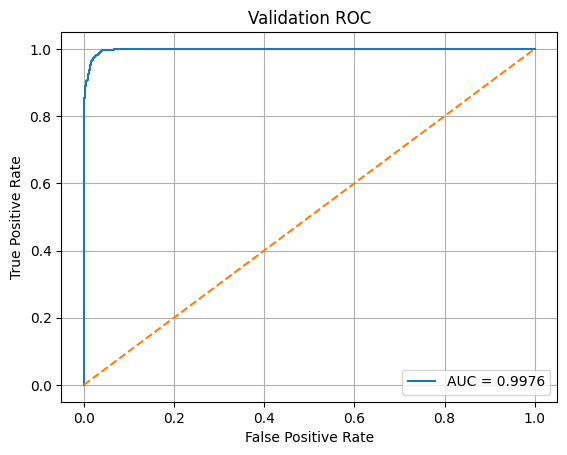

In [75]:
def plot_roc_curve(labels, probs, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

plot_roc_curve(val_metrics["labels"], val_metrics["probs"], "Validation ROC")

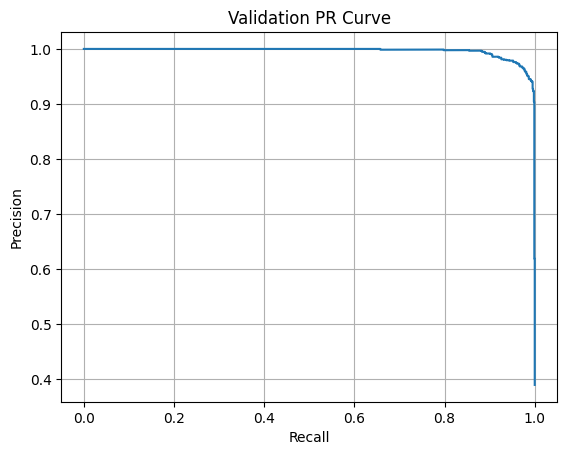

In [76]:
def plot_pr_curve(labels, probs, title="Precision-Recall Curve"):
    precision, recall, _ = precision_recall_curve(labels, probs)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.grid()
    plt.show()

plot_pr_curve(val_metrics["labels"], val_metrics["probs"], "Validation PR Curve")

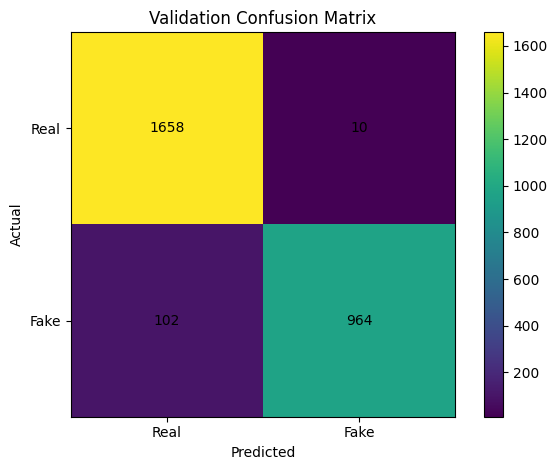

In [77]:
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    classes = ["Real", "Fake"]
    tick_marks = range(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(val_metrics["confusion_matrix"], "Validation Confusion Matrix")